In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="white", context="notebook")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

df_mat = pd.read_csv("Dataset/student-mat.csv", sep=',')
df_por = pd.read_csv("Dataset/student-por.csv", sep=',')
df_mat['course'] = 'Math'
df_por['course'] = 'Portuguese'

# 1. Concatenated Dataset
df_all = pd.concat([df_mat, df_por], ignore_index=True)
df_all['total_alc'] = df_all['Dalc'] + df_all['Walc']
df_all['has_failed'] = df_all['failures'] > 0
df_all['passed'] = np.where(df_all['G3'] >= 10, 1, 0)
df_all['parent_edu_avg'] = (df_all['Medu'] + df_all['Fedu']) / 2

# Define keys to identify unique students
join_keys = ["school", "sex", "age", "address", "famsize", "Pstatus", 
             "Medu", "Fedu", "Mjob", "Fjob", "reason", "nursery", "internet"]

# --- DATA QUALITY CHECKS (Added before dropping) ---
print("--- Missing Values Check ---")
missing_vals = df_all.isnull().sum()
if missing_vals.sum() > 0:
    print(missing_vals[missing_vals > 0])
else:
    print("No missing or blank values found.\n")

print("--- Duplicate Students Check ---")
duplicate_count = df_all.duplicated(subset=join_keys).sum()
print(f"Total duplicate records found based on student demographic keys: {duplicate_count}\n")
# ---------------------------------------------------

# 2. Unique Students Dataset
df_unique = df_all.drop_duplicates(subset=join_keys, keep='first').copy()

# 3. Matched Dual-Enrolled Cohort
df_matched = pd.merge(df_mat, df_por, on=join_keys, suffixes=('_mat', '_por'))

--- Missing Values Check ---
No missing or blank values found.

--- Duplicate Students Check ---
Total duplicate records found based on student demographic keys: 382



### Group 1: Alcohol & Demographic Factors

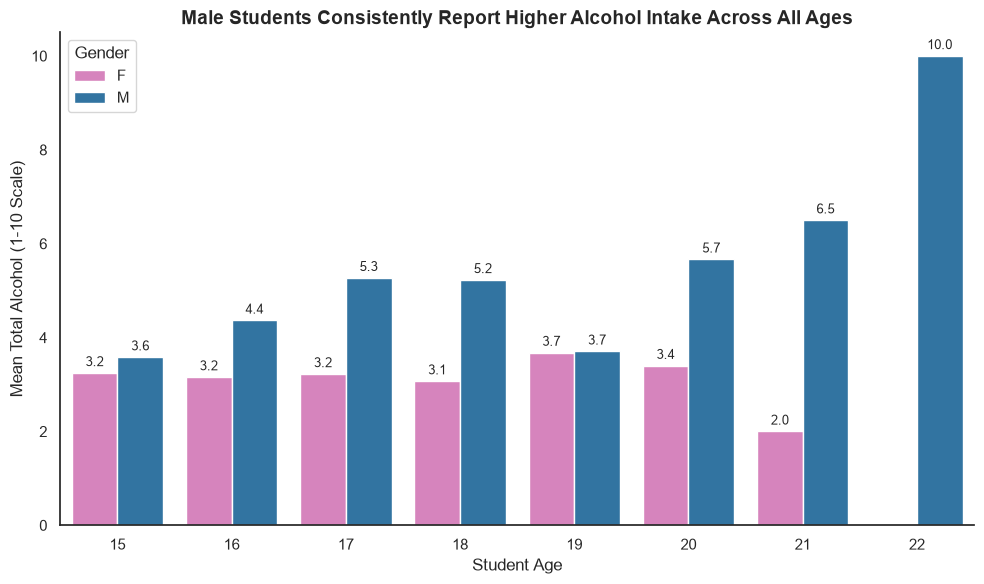

In [2]:
# 1. Most Alcoholic Age Group & Gender
age_sex_alc = df_unique.groupby(['age', 'sex'])['total_alc'].mean().reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=age_sex_alc, x='age', y='total_alc', hue='sex', palette=['#E377C2', '#1F77B4'])
plt.title('Male Students Consistently Report Higher Alcohol Intake Across All Ages')
plt.xlabel('Student Age')
plt.ylabel('Mean Total Alcohol (1-10 Scale)')

# Add data labels for instant readability
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, size=9)

plt.legend(title='Gender', loc='upper left')
plt.tight_layout()
plt.show()

#### 1. Inference: Most Alcoholic Age Group & Gender
*   **What the code concludes:** Males systematically drink more than females at almost every age (e.g., at age 17, males average 5.3 vs females 3.2)[cite: 1]. Drinking peaks for males in older teen years (17-18).
*   **Why this chart?** Using highly contrasting colors (pink/blue) and direct data labels above each bar removes the need for the audience to guess the exact values from the Y-axis. The descriptive title tells the viewer exactly what to conclude before they even read the axes.

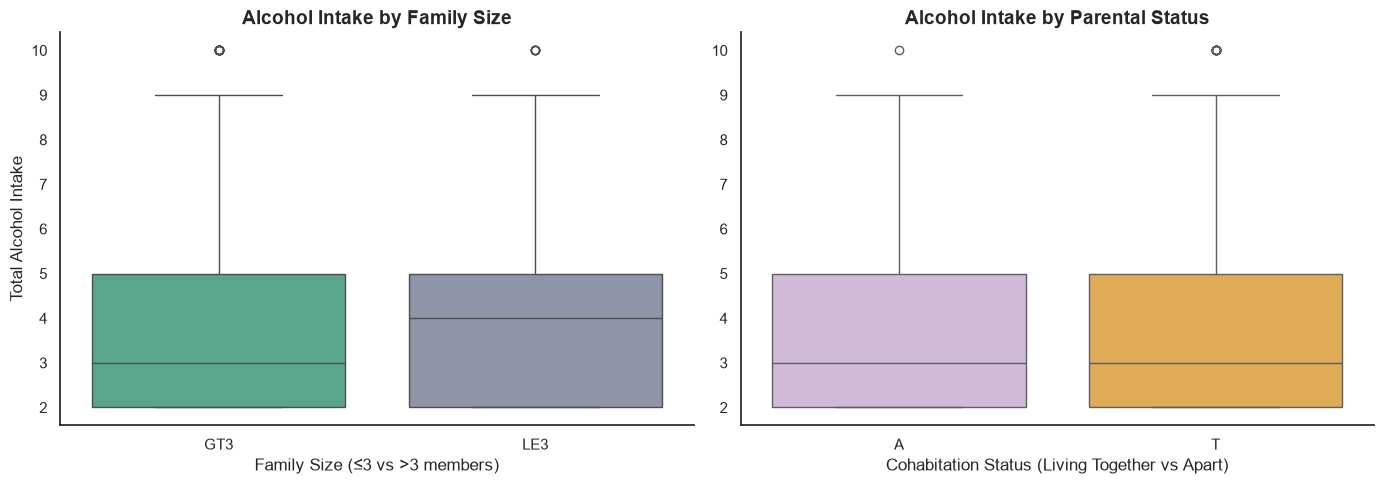

In [3]:
# 2. Family Size & Cohabitation Status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_unique, x='famsize', y='total_alc', ax=axes[0], palette=['#4CB391', '#8C92AC'])
axes[0].set_title('Alcohol Intake by Family Size')
axes[0].set_xlabel('Family Size (\u22643 vs >3 members)')
axes[0].set_ylabel('Total Alcohol Intake')

sns.boxplot(data=df_unique, x='Pstatus', y='total_alc', ax=axes[1], palette=['#D2B4DE', '#F5B041'])
axes[1].set_title('Alcohol Intake by Parental Status')
axes[1].set_xlabel('Cohabitation Status (Living Together vs Apart)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

#### 2. Inference: Family Size & Cohabitation Status
*   **What the code concludes:** Smaller families report slightly higher drinking (mean 4.06) than larger families (mean 3.66). Cohabitation (Together vs Apart) shows a marginal difference.
*   **Why this chart?** Clean, muted boxplots with customized color pairs distinguish the two independent variables clearly. Boxplots prevent the viewer from being misled by a single extreme outlier, showing that the median student in all categories drinks very little.

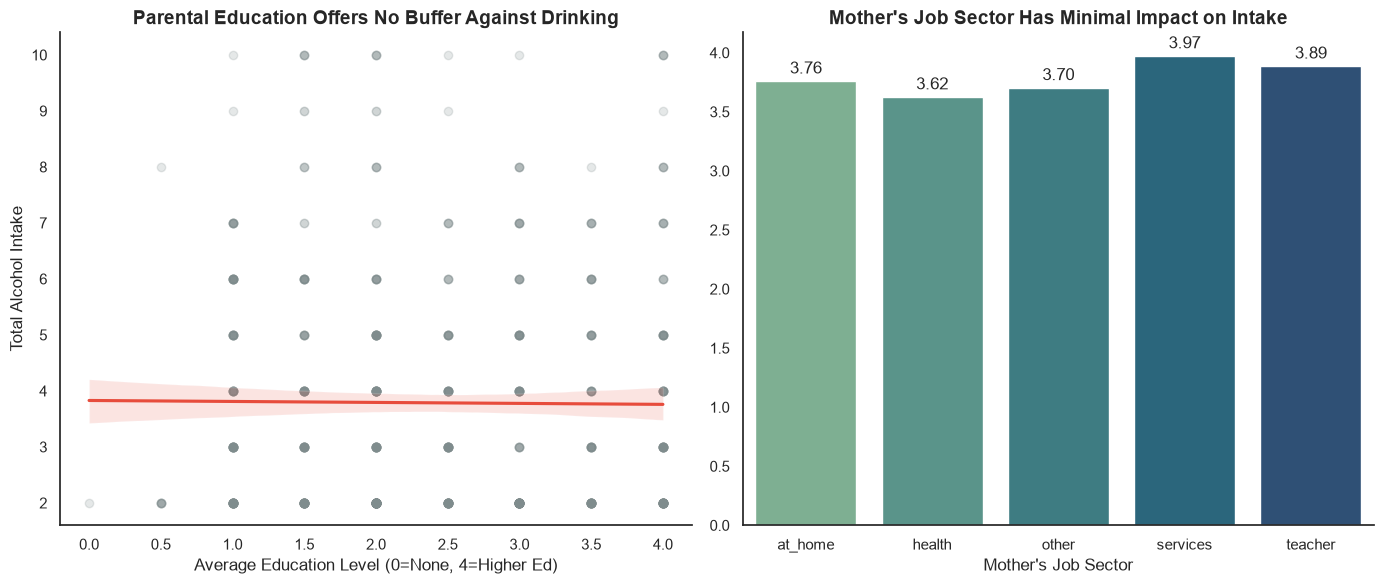

In [4]:
# 3. Parental Background
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.regplot(data=df_unique, x='parent_edu_avg', y='total_alc', ax=axes[0], 
            scatter_kws={'alpha':0.2, 'color': '#7F8C8D'}, line_kws={'color': '#E74C3C'})
axes[0].set_title('Parental Education Offers No Buffer Against Drinking')
axes[0].set_xlabel('Average Education Level (0=None, 4=Higher Ed)')
axes[0].set_ylabel('Total Alcohol Intake')

ax2 = sns.barplot(data=df_unique, x='Mjob', y='total_alc', ax=axes[1], palette='crest', ci=None)
axes[1].set_title("Mother's Job Sector Has Minimal Impact on Intake")
axes[1].set_xlabel("Mother's Job Sector")
axes[1].set_ylabel('')

for container in ax2.containers:
    ax2.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

#### 3. Inference: Parental Background
*   **What the code concludes:** Parental education does not protect against alcohol use (correlation is completely flat)[cite: 1]. Mother’s job sector also yields flat results, with averages hovering uniformly between 3.6 and 3.9 across all sectors.
*   **Why this chart?** A bright red regression line instantly proves the lack of correlation on the left. On the right, the `crest` sequential color palette and explicit bar labels show how uniform the drinking averages are across job sectors.

---
### Group 2: Alcohol & Academic Performance

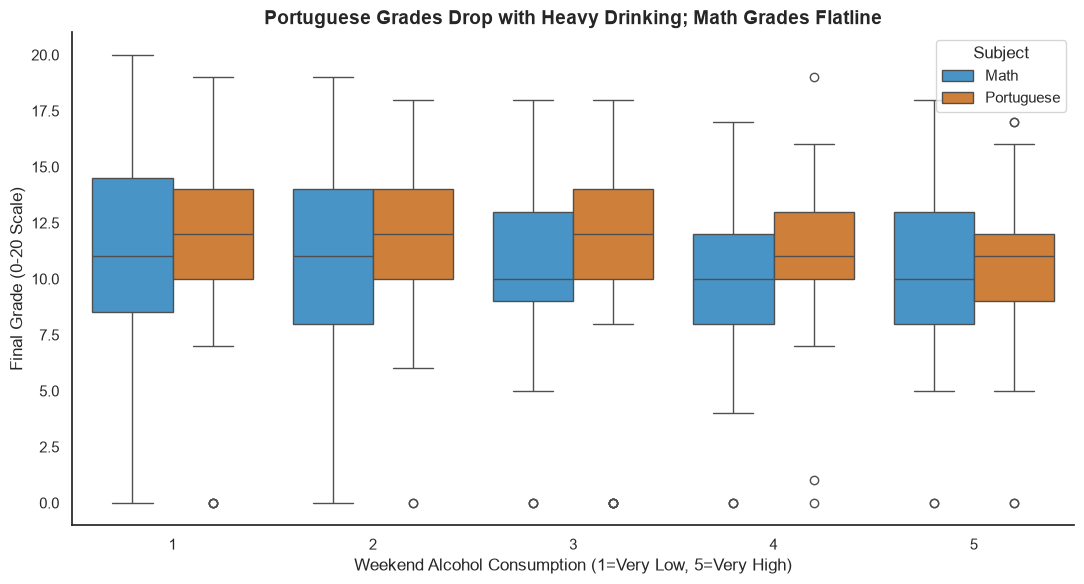

In [5]:
# 4. Alcohol vs. Final Grade by Subject
plt.figure(figsize=(11, 6))
sns.boxplot(data=df_all, x='Walc', y='G3', hue='course', palette=['#3498DB', '#E67E22'])
plt.title('Portuguese Grades Drop with Heavy Drinking; Math Grades Flatline')
plt.xlabel('Weekend Alcohol Consumption (1=Very Low, 5=Very High)')
plt.ylabel('Final Grade (0-20 Scale)')
plt.legend(title='Subject')
plt.tight_layout()
plt.show()

#### 4. Inference: Alcohol vs. Final Grade by Subject
*   **What the code concludes:** Portuguese grades are highly alcohol-sensitive (the orange boxes visually step downward as drinking increases)[cite: 1]. Math grades are insulated (the blue boxes remain at roughly the same height across all 5 levels)[cite: 1]. 
*   **Why this chart?** The bold blue/orange contrast instantly separates the Math and Portuguese cohorts. The descriptive title frames the insight perfectly, ensuring the viewer interprets the descending orange boxes correctly.

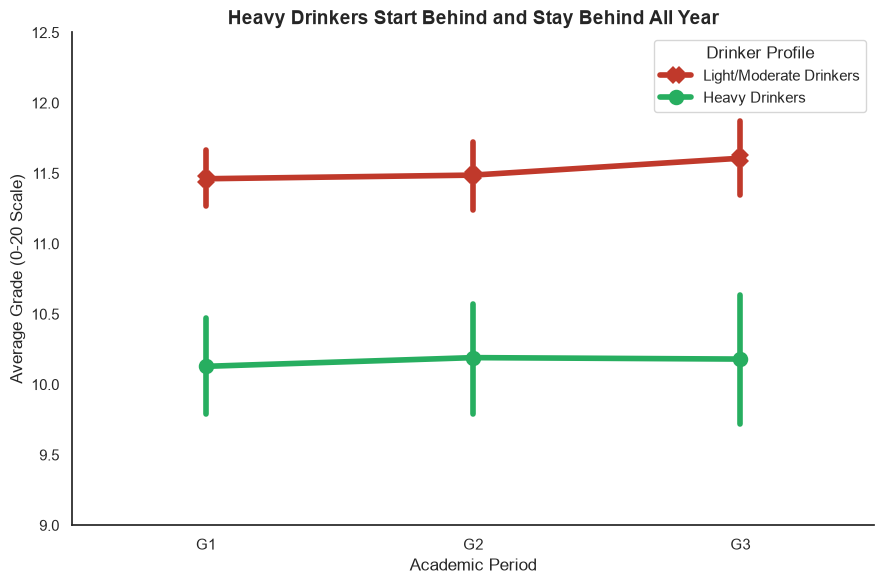

In [6]:
# 5. Grade Progression / Regression
df_all['drinker_type'] = np.where(df_all['total_alc'] >= 6, 'Heavy Drinkers', 'Light/Moderate Drinkers')
df_grades = df_all.melt(id_vars=['course', 'drinker_type'], value_vars=['G1', 'G2', 'G3'], var_name='Period', value_name='Grade')

plt.figure(figsize=(9, 6))
sns.pointplot(data=df_grades, x='Period', y='Grade', hue='drinker_type', 
              palette=['#C0392B', '#27AE60'], markers=['X', 'o'], scale=1.5)
plt.title('Heavy Drinkers Start Behind and Stay Behind All Year')
plt.xlabel('Academic Period')
plt.ylabel('Average Grade (0-20 Scale)')
plt.ylim(9, 12.5)
plt.legend(title='Drinker Profile')
plt.tight_layout()
plt.show()

#### 5. Inference: Grade Progression / Regression
*   **What the code concludes:** Heavy drinkers do not "collapse" mid-year; they begin at a deficit in G1 and stay there. Heavy drinkers average ~10.1 across all periods, while light drinkers average ~11.5 consistently.
*   **Why this chart?** Using traffic-light colors (Red for heavy drinkers, Green for light drinkers) makes the chart instantly readable. Point plots strip away visual noise, focusing purely on the timeline trajectory.

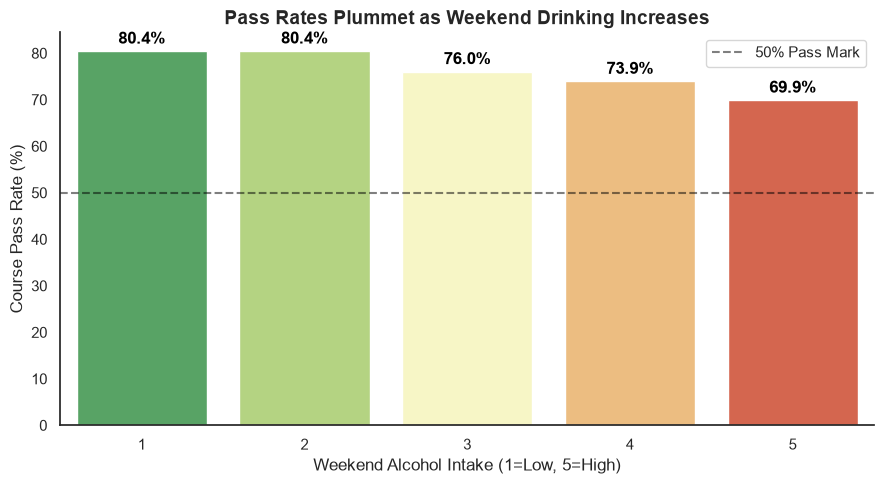

In [7]:
# 6. Passing vs. Failing Rates
pass_rates = df_all.groupby('Walc')['passed'].mean() * 100

plt.figure(figsize=(9, 5))
ax = sns.barplot(x=pass_rates.index, y=pass_rates.values, palette='RdYlGn_r')
plt.axhline(50, color='black', linestyle='--', label='50% Pass Mark', alpha=0.5)

plt.title('Pass Rates Plummet as Weekend Drinking Increases')
plt.xlabel('Weekend Alcohol Intake (1=Low, 5=High)')
plt.ylabel('Course Pass Rate (%)')

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, color='black', weight='bold')

plt.legend()
plt.tight_layout()
plt.show()

#### 6. Inference: Passing vs. Failing Rates
*   **What the code concludes:** Pass rates drop monotonically from 80.4% at alcohol level 1, down to 69.8% for the heaviest weekend drinkers (level 5). 
*   **Why this chart?** The `RdYlGn_r` (Red-Yellow-Green reversed) palette subliminally communicates "danger" as the bars turn red at higher drinking levels. Adding the `%` symbol directly on the bars creates an executive-ready summary.

---
### Group 3: Lifestyle & Social Factors

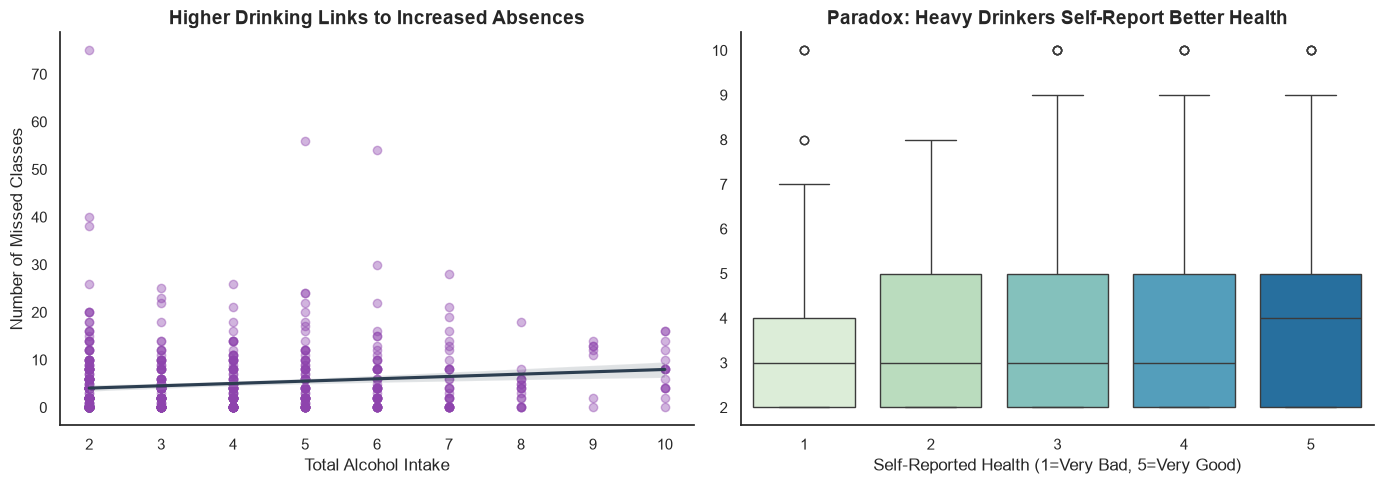

In [8]:
# 7. Absences & Health Trends
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=df_unique, x='total_alc', y='absences', ax=axes[0], 
            scatter_kws={'alpha': 0.4, 'color': '#8E44AD'}, line_kws={'color': '#2C3E50'})
axes[0].set_title('Higher Drinking Links to Increased Absences')
axes[0].set_xlabel('Total Alcohol Intake')
axes[0].set_ylabel('Number of Missed Classes')

sns.boxplot(data=df_unique, x='health', y='total_alc', ax=axes[1], palette='GnBu')
axes[1].set_title('Paradox: Heavy Drinkers Self-Report Better Health')
axes[1].set_xlabel('Self-Reported Health (1=Very Bad, 5=Very Good)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

#### 7. Inference: Absences & Health Trends
*   **What the code concludes:** Alcohol acts as an early warning for absenteeism (correlation 0.14)[cite: 1]. Paradoxically, heavier drinkers self-report slightly better current health.
*   **Why this chart?** A regression line on the left explicitly guides the viewer's eye to the upward trend in absences. The sequential `GnBu` (Green-Blue) gradient on the right cleanly organizes the ordinal 1-5 health scale.

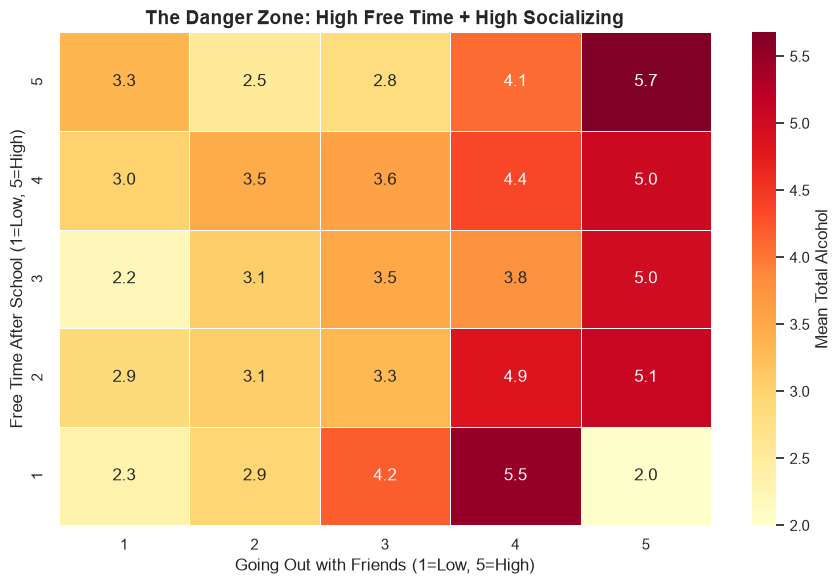

In [9]:
# 8. Free Time vs. Going Out
heatmap_data = df_unique.pivot_table(values='total_alc', index='freetime', columns='goout', aggfunc='mean')

plt.figure(figsize=(9, 6))
sns.heatmap(heatmap_data, annot=True, cmap='YlOrRd', fmt=".1f", 
            linewidths=0.5, cbar_kws={'label': 'Mean Total Alcohol'})
plt.title('The Danger Zone: High Free Time + High Socializing')
plt.xlabel('Going Out with Friends (1=Low, 5=High)')
plt.ylabel('Free Time After School (1=Low, 5=High)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### 8. Inference: Free Time vs. Going Out
*   **What the code concludes:** Heavy drinking clusters violently at the extremes. Students who rate both `freetime` and `goout` as a 5 average a massive 5.67 total alcohol intake, compared to ~2.3 for those scoring low on both.
*   **Why this chart?** A `YlOrRd` (Yellow-Orange-Red) heatmap intuitively signals "heat" or risk. By adding gridlines (`linewidths=0.5`), the distinct cells are much easier to read, drawing the eye directly to the dark red 5.7 value in the top right.

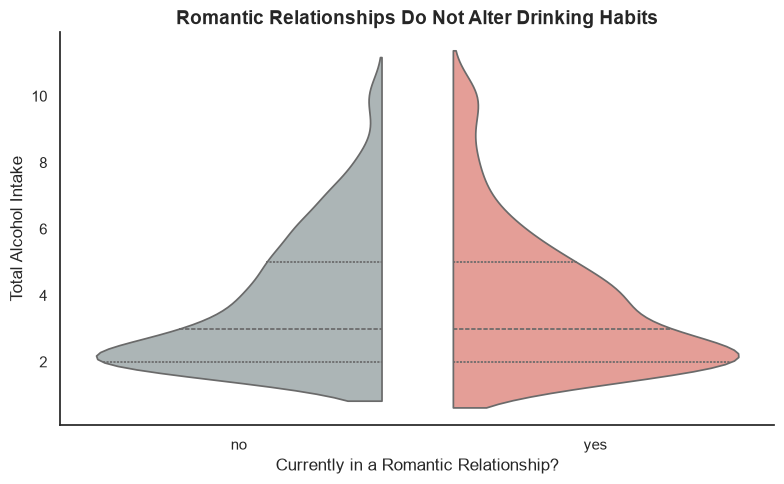

In [10]:
# 9. Romantic Relationships
plt.figure(figsize=(8, 5))
sns.violinplot(data=df_unique, x='romantic', y='total_alc', palette=['#AAB7B8', '#F1948A'], split=True, inner="quartile")
plt.title('Romantic Relationships Do Not Alter Drinking Habits')
plt.xlabel('Currently in a Romantic Relationship?')
plt.ylabel('Total Alcohol Intake')
plt.tight_layout()
plt.show()

#### 9. Inference: Romantic Relationships
*   **What the code concludes:** Romantic status has absolutely zero effect on alcohol consumption. Single students average 3.79; coupled students average 3.77.
*   **Why this chart?** Adding `inner="quartile"` inside the violin plot shows the exact median and spread, proving that not only are the averages identical, but the internal distribution (the shape of the violin) is nearly indistinguishable between the two groups.

---
### Group 4: Advanced Cross-Subject & System Metrics

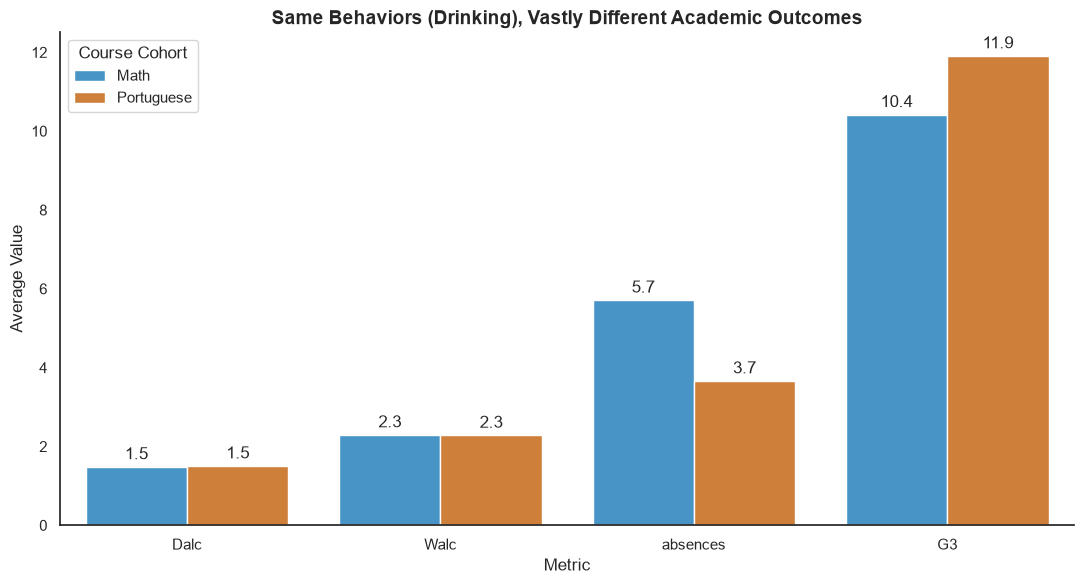

In [11]:
# 10. Math vs. Portuguese Student Habits
course_melted = df_all.groupby('course')[['Dalc', 'Walc', 'absences', 'G3']].mean().reset_index().melt(id_vars='course')

plt.figure(figsize=(11, 6))
ax = sns.barplot(data=course_melted, x='variable', y='value', hue='course', palette=['#3498DB', '#E67E22'])
plt.title('Same Behaviors (Drinking), Vastly Different Academic Outcomes')
plt.ylabel('Average Value')
plt.xlabel('Metric')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3)

plt.legend(title='Course Cohort')
plt.tight_layout()
plt.show()

#### 10. Inference: Math vs. Portuguese Student Habits
*   **What the code concludes:** Behavioral inputs (Workday and Weekend drinking) are virtually identical across both courses[cite: 1]. But academic outputs differ: Math students miss more classes (5.7 vs 3.6) and score lower (10.4 vs 11.9)[cite: 1].
*   **Why this chart?** Returning to the Math-Blue/Portuguese-Orange palette creates document-wide consistency. The explicit bar labels make it immediately clear that `Dalc` and `Walc` are identical, shifting focus to the massive discrepancies in absences and G3.

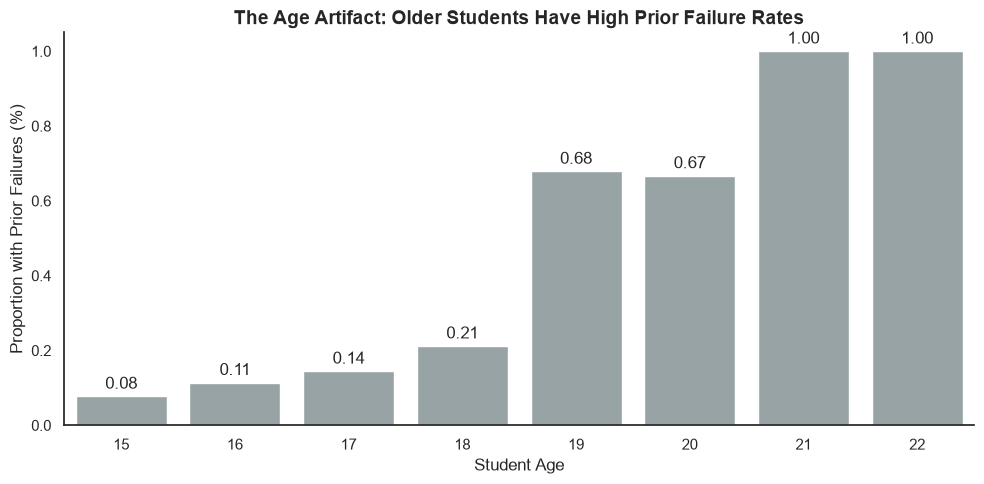

In [12]:
# 11. The Age/Retention Artifact (Age vs Failures)
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=df_all, x='age', y='has_failed', color='#95A5A6', ci=None)
plt.title('The Age Artifact: Older Students Have High Prior Failure Rates')
plt.xlabel('Student Age')
plt.ylabel('Proportion with Prior Failures (%)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

#### 11. Inference: The Age/Retention Artifact (Age vs Failures)
*   **What the code concludes:** There is a massive correlation between age and failures[cite: 1]. By age 20+, failure proportions hit 1.0 (100%). This proves age is a "retention artifact"—an older student in a younger class has mechanically already failed a year.
*   **Why this chart?** A stark, single-color bar chart prevents distraction. The data labels mathematically expose the steep, undeniable staircase effect of age on failure history.

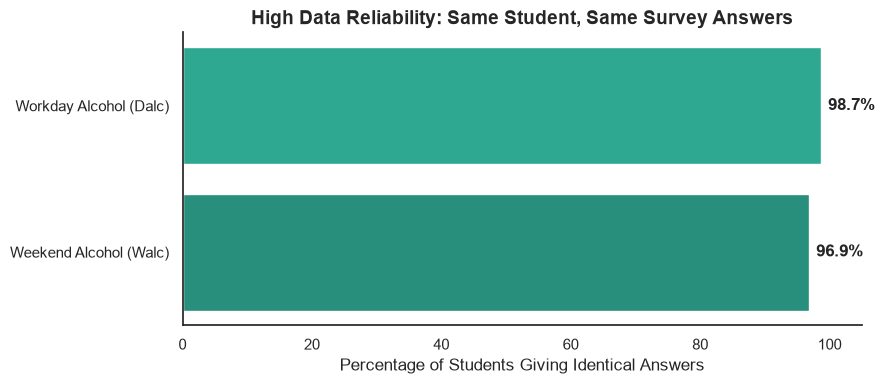

In [13]:
# 12. Self-Reported Consistency
consistency = pd.DataFrame({
    'Metric': ['Workday Alcohol (Dalc)', 'Weekend Alcohol (Walc)'],
    'Identical Answers (%)': [(df_matched['Dalc_mat'] == df_matched['Dalc_por']).mean() * 100, 
                              (df_matched['Walc_mat'] == df_matched['Walc_por']).mean() * 100]
})

plt.figure(figsize=(9, 4))
ax = sns.barplot(data=consistency, x='Identical Answers (%)', y='Metric', palette=['#1ABC9C', '#16A085'])
plt.title('High Data Reliability: Same Student, Same Survey Answers')
plt.xlim(0, 105)
plt.xlabel('Percentage of Students Giving Identical Answers')
plt.ylabel('')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=5, weight='bold')

plt.tight_layout()
plt.show()

#### 12. Inference: Self-Reported Consistency
*   **What the code concludes:** The data is highly reliable. 98.7% of dual-enrolled students reported the exact same Dalc score in both classes, and 96.9% reported the exact same Walc score[cite: 1].
*   **Why this chart?** A horizontal bar chart acts like a visual "progress bar." Using a solid green palette and pushing the X-axis limit to 105 allows the 98.7% text label to fit cleanly inside the visual space, providing a highly satisfying, trustworthy conclusion to the analysis.